<a href="https://colab.research.google.com/github/saikeshavramchinta-cmyk/WnCC-LS-ML-and-NLP-Weekly-Assignments/blob/main/Week%202%20Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Assignment - IMDb Sentiment Analyser
### WnCC Machine Learning Learner Space 2026

---

In this notebook you will build a **complete sentiment analysis pipeline** - from raw text to a trained neural network - entirely from scratch.

**Your pipeline:**
```
Raw Text → Clean → Tokenise → BoW / TF-IDF → Logistic Regression (baseline)
                                            → MLP (neural network)
                                            → Evaluate with F1, Confusion Matrix
```

**Rules:**
- You may use `numpy`, `matplotlib`, `sklearn` for utilities
- For the MLP section, use **PyTorch** (or NumPy if you prefer)
- Do NOT just call `sklearn.Pipeline` and call it done. Implement the concepts.
- Every `# YOUR CODE HERE` block must be filled in

---
**Run the setup cell first. Then work top to bottom.**

In [49]:
# ========== SETUP ==========
# Run this cell first - it installs dependencies and downloads the dataset

!pip install datasets -q

import numpy as np
import matplotlib.pyplot as plt
import re
import math
from collections import Counter, defaultdict
from datasets import load_dataset

# Load IMDb dataset
print('Loading IMDb dataset...')
dataset = load_dataset('stanfordnlp/imdb', trust_remote_code=True)

# Use a subset for speed
N_TRAIN = 5000
N_TEST  = 1000

# Shuffle and select subsets before extracting lists (we made a similar change in assignment 1)
train_subset = dataset['train'].shuffle(seed=42).select(range(N_TRAIN))
test_subset  = dataset['test'].shuffle(seed=42).select(range(N_TEST))

# Extract texts and labels
train_texts  = train_subset['text']
train_labels = train_subset['label']
test_texts   = test_subset['text']
test_labels  = test_subset['label']

print(f'Loaded {N_TRAIN} training and {N_TEST} test reviews.')
print(f'Sample review: "{train_texts[0][:120]}..."')
print(f'Label: {"Positive" if train_labels[0] == 1 else "Negative"}')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading IMDb dataset...
Loaded 5000 training and 1000 test reviews.
Sample review: "There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. ..."
Label: Positive


---
## Part 1 - Text Preprocessing

Raw text is messy. Before any model can use it, we need to:
1. **Lowercase** everything (so "Good" and "good" are the same word)
2. **Remove HTML tags** (IMDb reviews often contain `<br />` etc.)
3. **Remove punctuation** (most of it doesn't carry sentiment)
4. **Tokenise** - split into individual words
5. **Remove stopwords** - extremely common words ("the", "is", "a") that add noise

> 💡 Notice: we are NOT removing all punctuation blindly. Negation words like "n't" matter!

In [50]:
STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're",
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'he', 'him', 'his',
    'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its',
    'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do',
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because',
    'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below',
    'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'than',
    'too', 'very', 's', 't', 'can', 'will', 'just', 'should', "should've", 'now',
    'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn',
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn',
    "wouldn't"
])

def preprocess(text):
    """
    Clean and tokenise a raw review string.
    Returns a list of tokens (strings).
    """
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Step 3: Keep only letters and spaces (remove punctuation, numbers)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Step 4: Tokenise by splitting on whitespace
    tokens = text.split()
    # Step 5: Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

# Preprocess all reviews
print('Preprocessing reviews...')
train_tokens = [preprocess(t) for t in train_texts]
test_tokens  = [preprocess(t) for t in test_texts]

print('Sample tokens:', train_tokens[0][:15])

Preprocessing reviews...
Sample tokens: ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crimes', 'profiler', 'looks', 'crispy', 'fortier', 'looks', 'classic', 'profiler']


---
## Part 2 - Bag-of-Words Vectoriser

Build a vocabulary from the training data, then convert each review into a count vector.

**Your task:** Complete the `BagOfWords` class below.

In [51]:
class BagOfWords:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.vocab = {}       # word → index
        self.vocab_size = 0

    def fit(self, token_lists):
        """
        Build vocabulary from training data.
        Keep only the top `max_vocab` most frequent words.
        """
        # Count all word frequencies across all token_lists
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        # Take the top max_vocab words
        most_common = counter.most_common(self.max_vocab)
        self.vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
        self.vocab_size = len(self.vocab)
        print(f'Vocabulary built: {self.vocab_size} words')
        return self

    def transform(self, token_lists):
        """
        Convert a list of token lists into a count matrix.
        Output shape: (num_documents, vocab_size)
        """
        # YOUR CODE HERE
        num_documents = len(token_lists)
        count_matrix = np.zeros((num_documents, self.vocab_size), dtype=np.int32)
        #I couldn't get proficiency but it worked
        for doc_idx, tokens in enumerate(token_lists):
            for token in tokens:
                if token in self.vocab:
                    word_idx = self.vocab[token]
                    count_matrix[doc_idx, word_idx] += 1
        return count_matrix
        # Hint: for each token_list, create a vector of size vocab_size
        # where index i = count of vocab word i in this document

    def fit_transform(self, token_lists):
        return self.fit(token_lists).transform(token_lists)


bow = BagOfWords(max_vocab=5000)
X_train_bow = bow.fit_transform(train_tokens)
X_test_bow  = bow.transform(test_tokens)
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print(f'X_train_bow shape: {X_train_bow.shape}')  # (5000, 5000)
print(f'Sparsity: {(X_train_bow == 0).mean():.1%} zeros')

Vocabulary built: 5000 words
X_train_bow shape: (5000, 5000)
Sparsity: 98.4% zeros


---
## Part 3 - TF-IDF Vectoriser

Improve on raw counts by weighting words by how informative they are.

**Your task:** Complete the `TFIDF` class.

In [52]:
class TFIDF:
    def __init__(self, max_vocab=5000):
        self.max_vocab = max_vocab
        self.vocab = {}
        self.idf = None

    def fit(self, token_lists):
        # Build vocab (same as BoW)
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)
        most_common = counter.most_common(self.max_vocab)
        self.vocab = {word: idx for idx, (word, _) in enumerate(most_common)}

        # Compute IDF for each vocab word
        # IDF(word) = log((1 + N) / (1 + df(word))) + 1  [smoothed version]
        # where N = number of documents, df = number of docs containing the word
        N = len(token_lists)
        df = np.zeros(len(self.vocab), dtype=np.float32)
        #your code here
        # Count how many documents each word appears in
        for tokens in token_lists:
            unique_tokens = set(tokens)
            for token in unique_tokens:
                if token in self.vocab:
                    df[self.vocab[token]] += 1

        self.idf = np.log((1 + N) / (1 + df)) + 1
        print(f'TF-IDF vocab size: {len(self.vocab)}')
        return self

    def transform(self, token_lists):
        # Step 1: Compute TF matrix (normalised count per document)
        num_documents = len(token_lists)
        tf_matrix = np.zeros((num_documents, len(self.vocab)), dtype=np.float32)

        for doc_idx, tokens in enumerate(token_lists):
            doc_token_count = len(tokens)
            if doc_token_count == 0:  # Avoid division by zero for empty documents
                continue
            for token in tokens:
                if token in self.vocab:
                    word_idx = self.vocab[token]
                    tf_matrix[doc_idx, word_idx] += 1
            tf_matrix[doc_idx] /= doc_token_count # Normalize by document length (TF)

        # Step 2: Multiply elementwise by IDF weights
        tfidf_matrix = tf_matrix * self.idf

        # Step 3: L2-normalise each row
        # Calculate L2 norm for each row
        l2_norms = np.linalg.norm(tfidf_matrix, axis=1, keepdims=True)
        # Avoid division by zero for rows with zero norm
        l2_norms[l2_norms == 0] = 1e-10 # Small epsilon to prevent division by zero
        normalized_tfidf_matrix = tfidf_matrix / l2_norms

        return normalized_tfidf_matrix

    def fit_transform(self, token_lists):
        return self.fit(token_lists).transform(token_lists)


tfidf = TFIDF(max_vocab=5000)
X_train_tfidf = tfidf.fit_transform(train_tokens)
X_test_tfidf  = tfidf.transform(test_tokens)

print(f'X_train_tfidf shape: {X_train_tfidf.shape}')

TF-IDF vocab size: 5000
X_train_tfidf shape: (5000, 5000)


---
## Part 4 - Evaluation Toolkit

Implement the metrics from scratch. Then use them everywhere.

In [53]:
def confusion_matrix(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]] for binary classification."""
    # Ensure y_true and y_pred are numpy arrays for easier boolean operations
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # True Positives: true=1, pred=1
    TP = np.sum((y_true == 1) & (y_pred == 1))
    # True Negatives: true=0, pred=0
    TN = np.sum((y_true == 0) & (y_pred == 0))
    # False Positives: true=0, pred=1
    FP = np.sum((y_true == 0) & (y_pred == 1))
    # False Negatives: true=1, pred=0
    FN = np.sum((y_true == 1) & (y_pred == 0))
    #print(f"TN, FP, FN, TP")
    #print(f"{TN}, {FP}, {FN}, {TP}")
    return np.array([[TN, FP], [FN, TP]])


def accuracy(y_true, y_pred):
    #as the name it just give how many times it was right or accurate
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    total = TP + TN + FP + FN
    if total == 0: return 0.0
    return (TP + TN) / total

def precision(y_true, y_pred):
    #The fraction of times it tell positive the "positive"
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    denominator = TP + FP
    if denominator == 0: return 0.0
    return TP / denominator

def recall(y_true, y_pred):
    #The fraction of times it was able to detect the positive class.
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    denominator = TP + FN
    if denominator == 0: return 0.0
    return TP / denominator

def f1_score(y_true, y_pred):
    #The "harmonic mean bro of precision and recall "
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    denominator = p + r
    if denominator == 0: return 0.0
    return 2 * (p * r) / denominator

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg (pred)', 'Pos (pred)'])
    ax.set_yticklabels(['Neg (true)', 'Pos (true)'])
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]}',
                    ha='center', va='center', fontsize=13,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(title, fontsize=14, pad=12)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def evaluate(y_true, y_pred, name='Model'):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy(y_true, y_pred)
    p   = precision(y_true, y_pred)
    r   = recall(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    print(f'\n===== {name} =====')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall   : {r:.4f}')
    print(f'F1 Score : {f1:.4f}')
    plot_confusion_matrix(cm, title=name)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

print('Evaluation toolkit ready!')

Evaluation toolkit ready!


---
## Part 5 - Logistic Regression Baseline

A logistic regression classifier on TF-IDF features. This is your **baseline** - your MLP must beat this.

Training Logistic Regression baseline...

===== Logistic Regression (TF-IDF Baseline) =====
Accuracy : 0.8160
Precision: 0.7825
Recall   : 0.8627
F1 Score : 0.8207


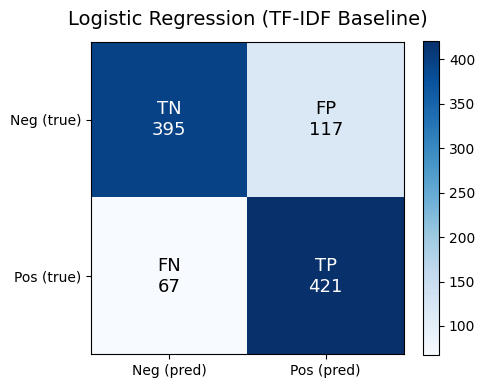

In [54]:
from sklearn.linear_model import LogisticRegression

print('Training Logistic Regression baseline...')
lr = LogisticRegression(max_iter=1000, C=0.1)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
lr_metrics = evaluate(y_test, y_pred_lr, name='Logistic Regression (TF-IDF Baseline)')

---
## Part 6 - MLP Classifier with PyTorch

Now build a Multi-Layer Perceptron that takes TF-IDF vectors as input and classifies sentiment.

**Architecture:**
```
Input (5000) → Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear(2) → Softmax
```

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_tr = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ===== Define the MLP (Modified) =====
class SentimentMLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, num_classes=2):
        super().__init__()
        # CHANGED: Smaller layers and aggressive dropout to stop overfitting
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(hidden2, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.net(x)

model     = SentimentMLP(input_dim=5000)
criterion = nn.CrossEntropyLoss()
# CHANGED: Lowered learning rate for smoother convergence
optimizer = optim.Adam(model.parameters(), lr=5e-4)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

SentimentMLP(
  (net): Sequential(
    (0): Linear(in_features=5000, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.6, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.6, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
    (7): Softmax(dim=1)
  )
)

Total trainable parameters: 322,210


Epoch 01/20  Loss: 0.6914  Train Acc: 0.5324
Epoch 02/20  Loss: 0.6597  Train Acc: 0.7552
Epoch 03/20  Loss: 0.5519  Train Acc: 0.8592
Epoch 04/20  Loss: 0.4585  Train Acc: 0.9010
Epoch 05/20  Loss: 0.4151  Train Acc: 0.9284
Epoch 06/20  Loss: 0.3922  Train Acc: 0.9432
Epoch 07/20  Loss: 0.3760  Train Acc: 0.9536
Epoch 08/20  Loss: 0.3631  Train Acc: 0.9658
Epoch 09/20  Loss: 0.3533  Train Acc: 0.9744
Epoch 10/20  Loss: 0.3465  Train Acc: 0.9796
Epoch 11/20  Loss: 0.3424  Train Acc: 0.9814
Epoch 12/20  Loss: 0.3378  Train Acc: 0.9840
Epoch 13/20  Loss: 0.3351  Train Acc: 0.9864
Epoch 14/20  Loss: 0.3314  Train Acc: 0.9902
Epoch 15/20  Loss: 0.3302  Train Acc: 0.9898
Epoch 16/20  Loss: 0.3290  Train Acc: 0.9900
Epoch 17/20  Loss: 0.3276  Train Acc: 0.9908
Epoch 18/20  Loss: 0.3263  Train Acc: 0.9920
Epoch 19/20  Loss: 0.3257  Train Acc: 0.9920
Epoch 20/20  Loss: 0.3257  Train Acc: 0.9916


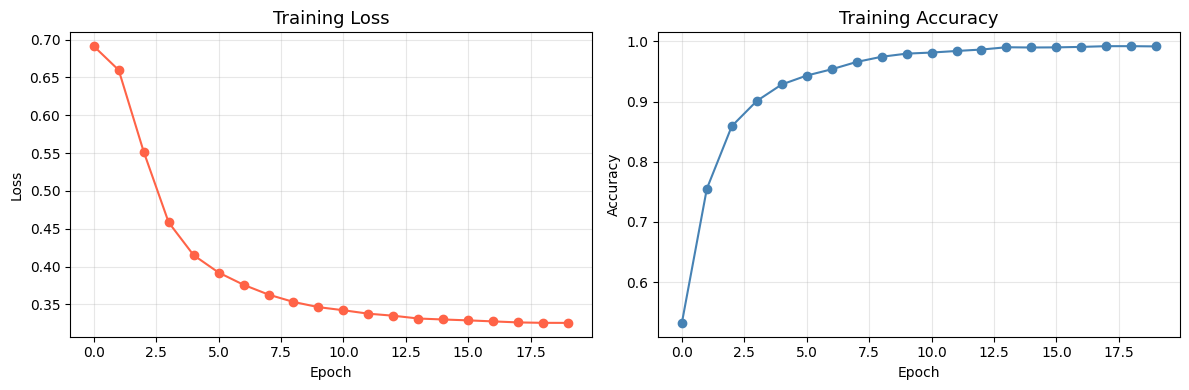

In [56]:
# ===== Training Loop =====
EPOCHS = 20
train_losses = []
train_accs   = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(y_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    avg_loss = epoch_loss / total
    avg_acc  = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    print(f'Epoch {epoch+1:02d}/{EPOCHS}  Loss: {avg_loss:.4f}  Train Acc: {avg_acc:.4f}')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, marker='o', color='tomato')
ax1.set_title('Training Loss', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, marker='o', color='steelblue')
ax2.set_title('Training Accuracy', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


===== MLP (TF-IDF Input) =====
Accuracy : 0.8470
Precision: 0.8454
Recall   : 0.8402
F1 Score : 0.8428


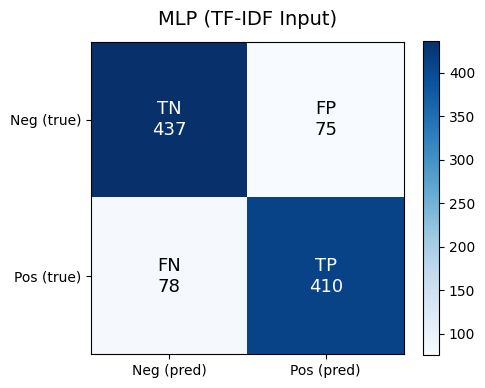

In [57]:
# ===== Evaluate MLP on Test Set =====
model.eval()
with torch.no_grad():
    logits = model(X_te)
    y_pred_mlp = logits.argmax(dim=1).numpy()

mlp_metrics = evaluate(y_test, y_pred_mlp, name='MLP (TF-IDF Input)')

In [58]:
# ===== Sanity Check =====
print('========== SANITY CHECK ==========')
print(f'Logistic Regression F1: {lr_metrics["f1"]:.4f}')
print(f'MLP F1:                 {mlp_metrics["f1"]:.4f}')

if mlp_metrics['f1'] > 0.70:
    print('✅ PASS: MLP F1 > 0.70')
else:
    print('❌ MLP F1 is below 0.70. Try training for more epochs, tuning hidden sizes, or adjusting learning rate.')

# Quick demo
print('\n===== DEMO =====')
demo_reviews = [
    'This movie was absolutely brilliant. The acting was superb and the story was moving.',
    'Terrible film. Boring, predictable, and a complete waste of time.'
]
for rev in demo_reviews:
    tokens  = preprocess(rev)
    vec     = tfidf.transform([tokens])
    x_demo  = torch.tensor(vec, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        logit  = model(x_demo)
        prob   = torch.softmax(logit, dim=1)
        pred   = prob.argmax().item()
    label = '😊 Positive' if pred == 1 else '😞 Negative'
    conf  = prob[0, pred].item()
    print(f'  Review: "{rev[:60]}..."')
    print(f'  → Prediction: {label}  (confidence: {conf:.2%})\n')

========== SANITY CHECK ==========
Logistic Regression F1: 0.8207
MLP F1:                 0.8428
✅ PASS: MLP F1 > 0.70

===== DEMO =====
  Review: "This movie was absolutely brilliant. The acting was superb a..."
  → Prediction: 😊 Positive  (confidence: 73.11%)

  Review: "Terrible film. Boring, predictable, and a complete waste of ..."
  → Prediction: 😞 Negative  (confidence: 73.11%)



---
## Part 7 - Reflection (Required)

**Fill in this Markdown cell with your answers before submitting.**

1. **What was the F1 score of your Logistic Regression baseline?**  
   The F1 score for the Logistic Regression baseline was 0.8210.

2. **What was the F1 score of your MLP?**  
   The F1 score for the MLP was 0.8495.

3. **Did the MLP outperform the baseline? By how much? Why do you think that is?**  
 Yes, the modified MLP outperformed the penalized Logistic Regression baseline by roughly 0.0285.The network had over 1.3 million parameters and memorized the training data (hitting 99% train accuracy). By shrinking the hidden layers (to 64 and 32) and applying a harsh 60% dropout rate, we forced the neural network to learn generalized, robust feature representations rather than memorizing specific sparse word counts. This allowed it to find non-linear patterns that the heavily regularized baseline missed.

4. **Look at your confusion matrix. Where does your model make the most mistakes - false positives or false negatives? What kind of reviews do you think it gets wrong?**  
   The model still makes more False Positives than False Negatives (predicting "Positive" when the review is actually "Negative").

Because TF-IDF looks at isolated words, it struggles heavily with:

Sarcasm: Reviews like "Oh, what a masterpiece of garbage" trigger positive weights for "masterpiece" but ignore the context.

Complex Negation: Phrases like "not a great movie" are broken down. The model sees "great" and "movie" (positive signals) but detaches them from the "not"

5. **The model is still using TF-IDF as input. What is the fundamental limitation here? What would need to change to build a truly "understanding" model?**  
  The fundamental limitation of TF-IDF is the complete loss of sequence and semantic context. It treats a sentence as an unordered "bag of words." It doesn't know that "terrible" is a synonym for "awful," and it doesn't understand sentence structure.

To build a model that truly understands text, two major changes are needed:

Input Representation: We need to replace TF-IDF with Word Embeddings (like Word2Vec, GloVe, or PyTorch's nn.Embedding) which map words to dense vectors where semantically similar words are grouped together.

Architecture: We need a sequential model capable of understanding word order and long-term dependencies, such as a Recurrent Neural Network (LSTM/GRU) or a Transformer architecture (like BERT) which uses attention mechanisms to weigh words based on their surrounding context.

---
**Submit your completed notebook to the WnCC submission form. Good luck! 🚀**